In [17]:
import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
random.seed(20)
np.random.seed(10)

In [18]:
def calculateErrorSurface(X, y):
    """
    Generate data points for plotting the error surface.
    X: design matrix
    y: labels (y = a1*x1 + a2*x2)
    A1, A2: meshgrid of the attributes
    J: MSE surface
    """
    # Get the number of examples.
    N = len(y)

    # Generate values for parameters.
    M = 100
    a1 = np.linspace(-12.0, 14.0, M)
    a2 = np.linspace(-12.0, 14.0, M)
    # Generate the mesh grid.
    A1, A2 = np.meshgrid(a1, a2)

    # Get the attributes
    x1 = X[:,0].reshape(N, 1)
    x2 = X[:,1].reshape(N, 1)
    # Generate points for plotting the cost-function surface.
    J = np.zeros((M,M))
    for iter1 in range(0, M):
        for iter2 in range(0, M):
            # Hypothesis function.
            yhat = A1[iter1, iter2]*x1 + A2[iter1, iter2]*x2
            # Calculate the MSE.
            J[iter1, iter2] = (1.0/N)*np.sum(np.square(y - yhat))
            
    

    return J, A1, A2

### Normal Equation Linear Regression

In [19]:
m = 1000
x1 = np.random.randn(m).reshape(m,1)
x2 = np.random.randn(m).reshape(m,1)
w = np.random.randn(m).reshape(m,1)
y_obj = 2*x1 + 1*x2
y_noisy = y_obj + w
X = np.c_[x1,x2]

a_opt = np.linalg.inv(X.T @ X) @ X.T @ y_noisy
print(a_opt)

[[1.99708072]
 [0.93386595]]


### minibatch gradient descent with fixed learning rate

In [20]:
def minibatch_gradient_descent(X,y,epochs,N,mb,alpha):
    """
    X: training examples
    y: training labels (y_noisy/funcao observavel)
    epochs: number of epochs
    m: number of examples
    mb: minibatch size
    alpha: learning rate/step size
    """

    m = X.shape[1] #number of attributes
    a = 10 * np.ones(m).reshape(m,1) # initial column vector of weights

    a_hist = np.zeros((epochs*int(N/mb),m)) # weight history
    mse_hist = np.zeros((epochs*int(N/mb))) # error history
    update_hist = np.zeros((epochs*N,m))      # learning rate * gradient
    it = 0
    
    for e in range(epochs):
        shuffled_indexes = random.sample(range(0, N), N) # Shuffling the whole dataset before every epoch.

        for i in range(0,N,mb):
            # Randomly selecting mb training examples
            random_indexes = tuple(shuffled_indexes[i:i+mb])
            xi = X[random_indexes,:]
            yi = y[random_indexes,:]

            yi_hat = xi @ a                      # funcao hipotese
            grad = (-2 * ((yi-yi_hat).T @ xi)).T # column vector of the gradient of the mse function
            a = a - alpha * (1/mb) * grad        # weight update

            # Saving all the histories
            a_hist[it,:] = a.reshape(1,m)
            mse_hist[it] = (1/N) * np.sum((yi-yi_hat)**2)
            update_hist[it,:] = (alpha * grad).reshape(1,m)

            it+=1

    
    return a, a_hist, mse_hist, update_hist


In [21]:
epochs = 10
mini_batch_size = 1 #1 = stochastic GD, m = classic GD
alpha = 0.01
a, a_hist, mse_hist, update_hist = minibatch_gradient_descent(X,y_noisy,epochs,m,mini_batch_size,alpha)
h = X @ a
print(a)

[[1.99879005]
 [0.94314944]]


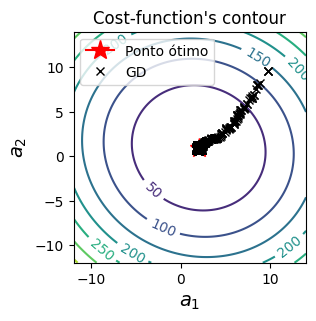

In [22]:
J, A1, A2 = calculateErrorSurface(X,y_noisy)
fig = plt.figure(figsize=(3,3))

cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('Cost-function\'s contour')

plt.plot(a_opt[0], a_opt[1], c='r', marker='*', markersize=14, label='Ponto ótimo')
plt.plot(a_hist[:, 0], a_hist[:, 1], 'kx', label='GD')

plt.legend()
plt.show()

### minibatch gradient descent using exponential weight decay

In [23]:
def minibatch_gradient_descent_decay(X,y,epochs,N,mb,alpha_0,k):
    """
    X: training examples
    y: training labels (y_noisy/funcao observavel)
    epochs: number of epochs
    N: number of examples
    mb: minibatch size
    alpha_0: initial learning rate/step size
    k: taxa de decrescimento
    """
    i_max = epochs * (N // mb)
    min_error = 1e-3
    error = 1

    m = X.shape[1] #number of attributes
    a = 10 * np.ones(m).reshape(m,1) # initial column vector of weights

    a_hist = np.zeros((i_max,m)) # weight history
    mse_hist = np.zeros((i_max)) # error history
    update_hist = np.zeros((i_max,m))      # learning rate * gradient
    it = 0
    it_epoch = 0
    epoch = 0

    while it < i_max and error > min_error:
        if it_epoch >= N or it==0:
            it_epoch=0
            epoch += 1
            if epoch >= epochs:
                break
            shuffled_indexes = random.sample(range(0, N), N) # Shuffling the whole dataset before each epoch
            
        batch_start = it_epoch
        # Randomly selecting mb training examples
        random_indexes = tuple(shuffled_indexes[batch_start:batch_start+mb])
        xi = X[random_indexes,:]
        yi = y[random_indexes,:]

        alpha = alpha_0 * np.exp(-k*it)      # LEARNING RATE WITH EXPONENTIAL DECAY
        yi_hat = xi @ a                      # funcao hipotese
        grad = (-2 * ((yi-yi_hat).T @ xi)).T # column vector of the gradient of the mse function
        a = a - alpha * (1/mb) * grad        # weight update

        # Saving all the histories
        a_hist[it,:] = a.reshape(1,m)
        mse_hist[it] = (1/mb) * np.sum((yi-yi_hat)**2)
        update_hist[it,:] = (alpha * grad).reshape(1,m)

        #updating the error
        if it > 0:
            error = np.abs(mse_hist[it]-mse_hist[it-1])
        else:   
            error = mse_hist[0]
        
        it+=1
        it_epoch+=mb

    
    return a, a_hist, mse_hist, update_hist


In [24]:
epochs = 10
mini_batch_size = 1 #1 = stochastic GD, m = classic GD
alpha_0 = 0.01
k = 0.1
a, a_hist, mse_hist, update_hist = minibatch_gradient_descent_decay(X,y_noisy,epochs,m,mini_batch_size,alpha_0,k)
h = X @ a
print(a)

[[8.02855309]
 [9.40059263]]


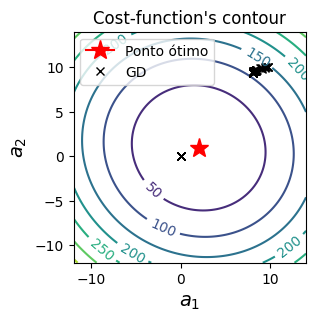

In [25]:
J, A1, A2 = calculateErrorSurface(X,y_noisy)
fig = plt.figure(figsize=(3,3))

cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('Cost-function\'s contour')

plt.plot(a_opt[0], a_opt[1], c='r', marker='*', markersize=14, label='Ponto ótimo')
plt.plot(a_hist[:, 0], a_hist[:, 1], 'kx', label='GD')

plt.legend()
plt.show()

### grid search (optimize k)

In [26]:
def grid_search(X,y_noisy,epochs,m,mini_batch_size,alpha_0):
    # Search between 10^-4 up to 1.025.
    decay_rates = [0.0001, 0.001, 0.01, 0.1, 1.0, 1.025]

    interations = []
    scores = []
    for k in decay_rates:
        a, a_hist, mse_hist, update_hist = minibatch_gradient_descent_decay(X,y_noisy,epochs,m,mini_batch_size,alpha_0,k)
        mse = (1.0/m)*np.sum(np.power(y_noisy - X@a, 2))
        scores.append(mse)
        interations.append(len(mse_hist[mse_hist!=0]))

    # Ajuste fino

    best_idx = np.argmin(scores)
    best_k = decay_rates[best_idx]
    fine_range = np.linspace(best_k/2, best_k*2, 10)
    fine_interations = []
    fine_scores = []
    for k in fine_range:
        a, a_hist, mse_hist, update_hist = minibatch_gradient_descent_decay(X,y_noisy,epochs,m,mini_batch_size,alpha_0,k)
        mse = (1.0/m)*np.sum(np.power(y_noisy - X@a, 2))
        fine_scores.append(mse)
        fine_interations.append(len(mse_hist[mse_hist!=0]))

    return fine_range[np.argmin(fine_scores)]

In [27]:
epochs = 10
mini_batch_size = 1 #1 = stochastic GD, m = classic GD
alpha_0 = 0.01
k = grid_search(X,y_noisy,epochs,m,mini_batch_size,alpha_0)
a, a_hist, mse_hist, update_hist = minibatch_gradient_descent_decay(X,y_noisy,epochs,m,mini_batch_size,alpha_0,k)
h = X @ a
print(a)

[[2.25980492]
 [0.96267044]]


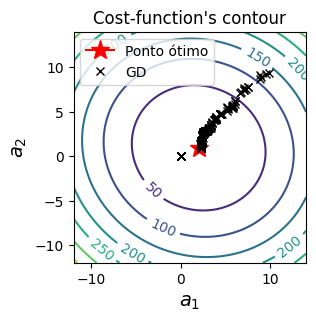

In [28]:
J, A1, A2 = calculateErrorSurface(X,y_noisy)
fig = plt.figure(figsize=(3,3))

cp = plt.contour(A1, A2, J)
plt.clabel(cp, inline=1, fontsize=10)
plt.xlabel('$a_1$', fontsize=14)
plt.ylabel('$a_2$', fontsize=14)
plt.title('Cost-function\'s contour')

plt.plot(a_opt[0], a_opt[1], c='r', marker='*', markersize=14, label='Ponto ótimo')
plt.plot(a_hist[:, 0], a_hist[:, 1], 'kx', label='GD')

plt.legend()
plt.show()